In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Prasad\Desktop\secure-bank-fraud-ml\data\PS_20174392719_1491204439457_log.csv")

In [3]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [6]:
fraud_percentage = df['isFraud'].value_counts(normalize=True) * 100

In [7]:
fraud_percentage

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [8]:
df.groupby("type")['isFraud'].mean()

type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64

In [9]:
df.groupby("type")['isFraud'].mean().index

Index(['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER'], dtype='object', name='type')

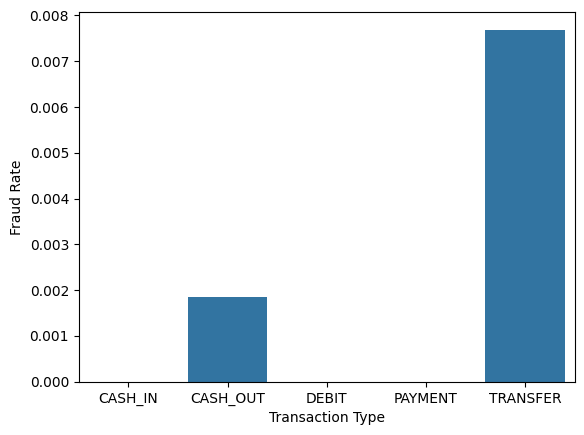

In [10]:
sns.barplot(x=df.groupby("type")["isFraud"].mean().index, 
           y = df.groupby("type")["isFraud"].mean().values)

plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")
plt.show()

In [11]:
(df['oldbalanceOrg'] - df['newbalanceOrig'] == df['amount']).value_counts()

False    5922109
True      440511
Name: count, dtype: int64

In [12]:
df['hour_of_day'] = (df['step'] - 1) % 24
df['day'] = (df['step']-1) // 24

In [13]:
df['log1p_amount'] = np.log1p(df['amount'])

In [14]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day,log1p_amount
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,0,9.194276
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,0,7.531166
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0,0,5.204007
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0,0,5.204007
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0,0,9.364703


In [15]:
(df['amount'] == 0).sum()

16

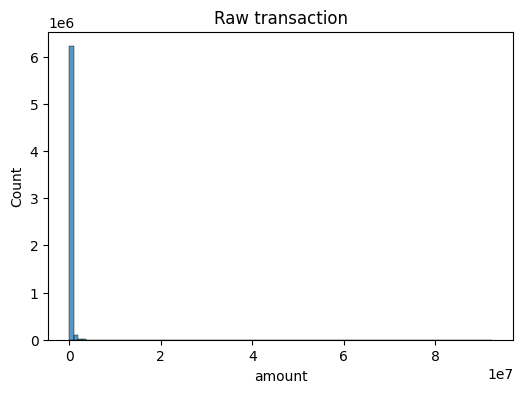

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['amount'], bins=100)
plt.title("Raw transaction")
plt.show()

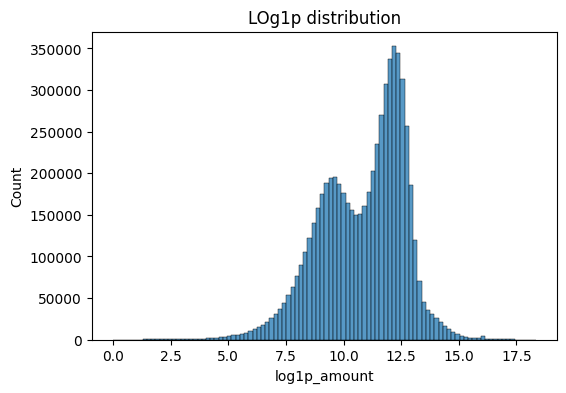

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['log1p_amount'], bins =100)
plt.title("LOg1p distribution")
plt.show()

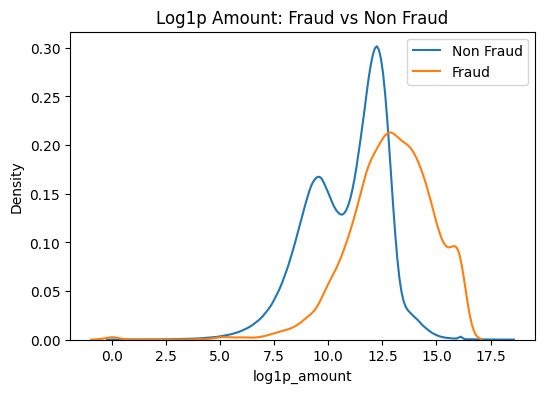

In [18]:
plt.figure(figsize=(6,4))
sns.kdeplot(df[df['isFraud']==0]['log1p_amount'], label="Non Fraud")
sns.kdeplot(df[df['isFraud']==1]['log1p_amount'], label='Fraud')
plt.legend()
plt.title("Log1p Amount: Fraud vs Non Fraud")
plt.show()

In [19]:
df['amount_to_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

In [20]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day,log1p_amount,amount_to_balance_ratio
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,0,9.194276,0.057834
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,0,7.531166,0.087731
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0,0,5.204007,0.994505
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0,0,5.204007,0.994505
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0,0,9.364703,0.280788


In [21]:
df['is_high_amount'] = (df['amount'] > df['amount'].quantile(0.99)).astype(int)

In [22]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day,log1p_amount,amount_to_balance_ratio,is_high_amount
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,0,9.194276,0.057834,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,0,7.531166,0.087731,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0,0,5.204007,0.994505,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0,0,5.204007,0.994505,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0,0,9.364703,0.280788,0


In [23]:
df['balance_diff_org'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_error'] = df['balance_diff_org'] - df['amount']

In [24]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day,log1p_amount,amount_to_balance_ratio,is_high_amount,balance_diff_org,balance_error
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,0,9.194276,0.057834,0,9839.64,1.455192e-11
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,0,7.531166,0.087731,0,1864.28,-1.136868e-12
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0,0,5.204007,0.994505,0,181.00,0.000000e+00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0,0,5.204007,0.994505,0,181.00,0.000000e+00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0,0,9.364703,0.280788,0,11668.14,0.000000e+00


In [25]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [26]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,day,log1p_amount,amount_to_balance_ratio,is_high_amount,balance_diff_org,balance_error,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,...,0,9.194276,0.057834,0,9839.64,1.455192e-11,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,...,0,7.531166,0.087731,0,1864.28,-1.136868e-12,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,...,0,5.204007,0.994505,0,181.00,0.000000e+00,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,...,0,5.204007,0.994505,0,181.00,0.000000e+00,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,...,0,9.364703,0.280788,0,11668.14,0.000000e+00,False,False,True,False


In [27]:
df = df.drop(columns=['nameOrig', 'nameDest', 'step'])

In [28]:
df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour_of_day,day,log1p_amount,amount_to_balance_ratio,is_high_amount,balance_diff_org,balance_error,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,160296.36,0.0,0.0,0,0,0,0,9.194276,0.057834,0,9839.64,1.455192e-11,False,False,True,False
1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0,0,7.531166,0.087731,0,1864.28,-1.136868e-12,False,False,True,False
2,181.00,181.0,0.00,0.0,0.0,1,0,0,0,5.204007,0.994505,0,181.00,0.000000e+00,False,False,False,True
3,181.00,181.0,0.00,21182.0,0.0,1,0,0,0,5.204007,0.994505,0,181.00,0.000000e+00,True,False,False,False
4,11668.14,41554.0,29885.86,0.0,0.0,0,0,0,0,9.364703,0.280788,0,11668.14,0.000000e+00,False,False,True,False


In [29]:
y = df['isFraud']

In [30]:
y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

In [31]:
X = df.drop(columns='isFraud')

In [32]:
X

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,hour_of_day,day,log1p_amount,amount_to_balance_ratio,is_high_amount,balance_diff_org,balance_error,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.00,160296.36,0.00,0.00,0,0,0,9.194276,0.057834,0,9839.64,1.455192e-11,False,False,True,False
1,1864.28,21249.00,19384.72,0.00,0.00,0,0,0,7.531166,0.087731,0,1864.28,-1.136868e-12,False,False,True,False
2,181.00,181.00,0.00,0.00,0.00,0,0,0,5.204007,0.994505,0,181.00,0.000000e+00,False,False,False,True
3,181.00,181.00,0.00,21182.00,0.00,0,0,0,5.204007,0.994505,0,181.00,0.000000e+00,True,False,False,False
4,11668.14,41554.00,29885.86,0.00,0.00,0,0,0,9.364703,0.280788,0,11668.14,0.000000e+00,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,339682.13,0.00,0.00,339682.13,0,22,30,12.735768,0.999997,0,339682.13,0.000000e+00,True,False,False,False
6362616,6311409.28,6311409.28,0.00,0.00,0.00,0,22,30,15.657870,1.000000,1,6311409.28,0.000000e+00,False,False,False,True
6362617,6311409.28,6311409.28,0.00,68488.84,6379898.11,0,22,30,15.657870,1.000000,1,6311409.28,0.000000e+00,True,False,False,False
6362618,850002.52,850002.52,0.00,0.00,0.00,0,22,30,13.652996,0.999999,0,850002.52,0.000000e+00,False,False,False,True


In [33]:
X.isna().sum()

amount                     0
oldbalanceOrg              0
newbalanceOrig             0
oldbalanceDest             0
newbalanceDest             0
isFlaggedFraud             0
hour_of_day                0
day                        0
log1p_amount               0
amount_to_balance_ratio    0
is_high_amount             0
balance_diff_org           0
balance_error              0
type_CASH_OUT              0
type_DEBIT                 0
type_PAYMENT               0
type_TRANSFER              0
dtype: int64

In [34]:
np.isinf(X).values.any()

False

In [35]:
X.isin([np.inf, -np.inf, 'inf', '-inf', 'Infinity', '-Infinity']).any().any()

False

In [36]:
X_test = X.apply(pd.to_numeric, errors='coerce')
print(np.isinf(X_test).any().any())


False


In [37]:
X.dtypes

amount                     float64
oldbalanceOrg              float64
newbalanceOrig             float64
oldbalanceDest             float64
newbalanceDest             float64
isFlaggedFraud               int64
hour_of_day                  int64
day                          int64
log1p_amount               float64
amount_to_balance_ratio    float64
is_high_amount               int32
balance_diff_org           float64
balance_error              float64
type_CASH_OUT                 bool
type_DEBIT                    bool
type_PAYMENT                  bool
type_TRANSFER                 bool
dtype: object

In [41]:
# df.to_parquet("data/paysim_eda_processed.parquet")
df.to_csv(r"C:\Users\Prasad\Desktop\secure-bank-fraud-ml\data\paysim_eda_processed.csv", index=False)
